In [1]:
!pip install tensorflow opencv-python mediapipe matplotlib scikit-learn pandas pillow

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import os

In [3]:
DATASET_PATH = r"C:\Users\prave\OneDrive\Desktop\jupyter notebook 333\skin_type_classification_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 30

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2872 files belonging to 4 classes.
Found 812 files belonging to 4 classes.
Found 409 files belonging to 4 classes.


In [6]:
class_names = train_ds.class_names

print(class_names)

['combination', 'dry', 'normal', 'oily']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [9]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

In [10]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [11]:
model.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
os.makedirs("models", exist_ok=True)

callbacks = [

    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=2,
        factor=0.2
    ),

    ModelCheckpoint(
        "models/skin_classifier.keras",
        save_best_only=True
    )
]

In [13]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.2789 - loss: 1.4103 - val_accuracy: 0.2808 - val_loss: 1.3449 - learning_rate: 1.0000e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.2994 - loss: 1.3640 - val_accuracy: 0.2906 - val_loss: 1.3209 - learning_rate: 1.0000e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 434s 5s/step - accuracy: 0.3210 - loss: 1.3387 - val_accuracy: 0.3103 - val_loss: 1.3072 - learning_rate: 1.0000e-04
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 306s 3s/step - accuracy: 0.3360 - loss: 1.3269 - val_accuracy: 0.3227 - val_loss: 1.2980 - learning_rate: 1.0000e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 301s 3s/step - accuracy: 0.3346 - loss: 1.3136 - val_accuracy: 0.3313 - val_loss: 1.2927 - learning_rate: 1.0000e-04
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.3464 - loss: 1.3070 - val_accuracy: 0.3473 - val_loss: 1.2873 - learning_rate: 1.0000e-04
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - accuracy: 0.3419 

In [14]:
loss, accuracy = model.evaluate(test_ds)

print(f"Test Accuracy : {accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4205 - loss: 1.1879
Test Accuracy : 42.05%


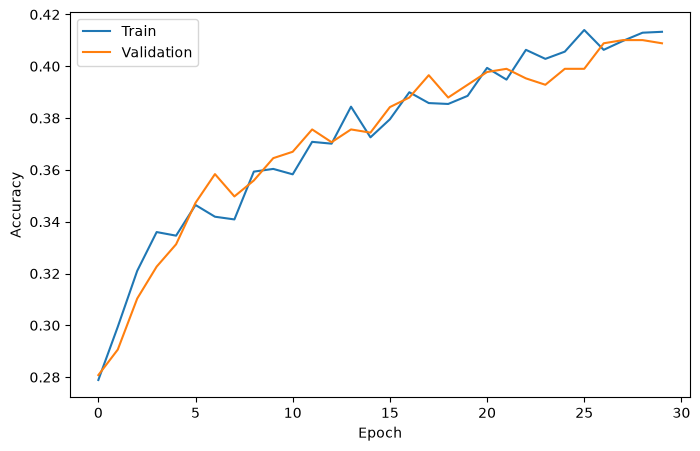

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

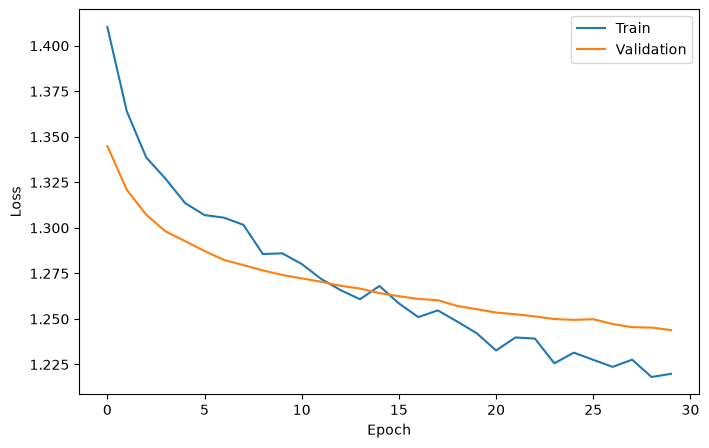

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [18]:
import pickle

with open("models/class_names.pkl","wb") as f:
    pickle.dump(class_names,f)